# **Züri wie neu Waste per Resident in the Neighbourhoods of Zürich**

Author: Tim Berger  
Date: 20.5.2026
<br>
<br>

### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city.  
Reports are sorted in different categories, such as waste or graphity.  
Illegal disposed waste and littering in the "Abfall/ Sammelstelle" category is reported the most (see category frequency analysis).  
As seen in the heatmap, the number of reports is, generally speaking, higher in the centre of Zürich, compared to the outer regions. But at the same time, also more people live in the city center compared to the outer regions.   Therefore this analysis aims to compare the heatmap with the number of waste reports per neighbourhood in the city of Zürich
<br>
<br>

### Research Question: 
Do the waste report hotspots on the heatmap correlate with the reports per resident for the neighbourhoods of zurich?
<br>
<br>

### Requirements
see README file
<br>
<br>

import packages


In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats
import contextily as ctx
import cmcrameri.cm as cmc

import notebook_utils

### Access and load data via Website of Zürich (züri wie neu, neighbourhoods, population)

In [2]:
# the notebook_utils file contains all the functions to load the required data from the website of the canton of zurich
# if a dataset failed to load, the corresponding url in the notebook utils file should be checked

zwn_gdf_raw = notebook_utils.import_zwn_data()
neighbourhoods_gdf_raw = notebook_utils.import_neighbourhood_data()
population_df_raw = notebook_utils.import_population_data()
income_df_raw = notebook_utils.import_income_data()
neighbourhood_labels_gdf_raw = notebook_utils.import_neighbourhood_label_data()


'Züri wie neu' data loaded sugessfully
neighbourhood data loaded sugessfully
population data loaded sugessfully
income data loaded sugessfully
neighbourhood label data loaded sugessfully


## Clean and Filter the Data

- clean population data

In [3]:
## filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

#clean the population data
#drop the columns not needed
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

#convert numbers to integer
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

#rename the columns
population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})



- clean züri wie neu data

In [4]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]


- clean neighbourhood data

In [5]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

# filter the neighbourhood label data for required columns
neighbourhood_labels_gdf = neighbourhood_labels_gdf_raw[["name", "geometry"]].copy()

## join and merge data together

In [6]:

#join the trash points to the neighbourhoods

waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")


#count the number of waste per neighbourhood and safe it as a dataframe waste_income_df
waste_pop_df = waste_with_neighbourhoods_df[["qname"]].value_counts().to_frame()

#rename the dataframe
waste_pop_df = waste_pop_df.rename(columns={"count":"count_waste"})

In [7]:
# merge the population to the neighbourhoods

waste_pop_df = pd.merge(right=waste_pop_df, 
                                        left=population_df,
                                        left_on="qname",
                                        right_on="qname")
waste_pop_df = waste_pop_df.sort_values(by="population", ascending=True)
waste_pop_df = waste_pop_df.set_index("qname")

In [8]:
# merge the population and waste to the geometry and calculate the pop density and waste per resident
waste_pop_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=waste_pop_df,
                                        left_on="qname",
                                        right_on="qname")

# calculate the population density
waste_pop_gdf["population_density"] = round(1000 *waste_pop_gdf["population"]/waste_pop_gdf.geometry.area,2)

# normalize the waste per 100 person
waste_pop_gdf["waste_per_pop"] = round(100* waste_pop_gdf["count_waste"]/waste_pop_gdf["population"],2) 

# normalize the waste per area
waste_pop_gdf["waste_per_area"] = round(1000000* waste_pop_gdf["count_waste"]/waste_pop_gdf.geometry.area)

# sort neighbourhoods by population density
waste_pop_gdf = waste_pop_gdf.sort_values(by= "waste_per_area", ascending=True)

# check if everything worked and how the data looks
waste_pop_gdf.head(5)



,qname,qnr,geometry,population,count_waste,population_density,waste_per_pop,waste_per_area
1,Witikon,74,"POLYGON ((2685858.618 1246502.677, 2685860.724...",11984,268,2.43,2.24,54.0
31,Friesenberg,33,"POLYGON ((2678931.42 1245766.698, 2678940.152 ...",11226,348,2.12,3.10,66.0
7,Leimbach,23,"POLYGON ((2680272.541 1242790.882, 2680279.745...",6316,263,2.16,4.16,90.0
14,Hottingen,72,"POLYGON ((2683859.976 1246754.268, 2683865.226...",11620,532,2.30,4.58,105.0
18,Affoltern,111,"POLYGON ((2678898.276 1253662.376, 2678898.573...",27439,792,4.54,2.89,131.0


## Plot Data

c:\Users\timbe\miniconda3\envs\sds210\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


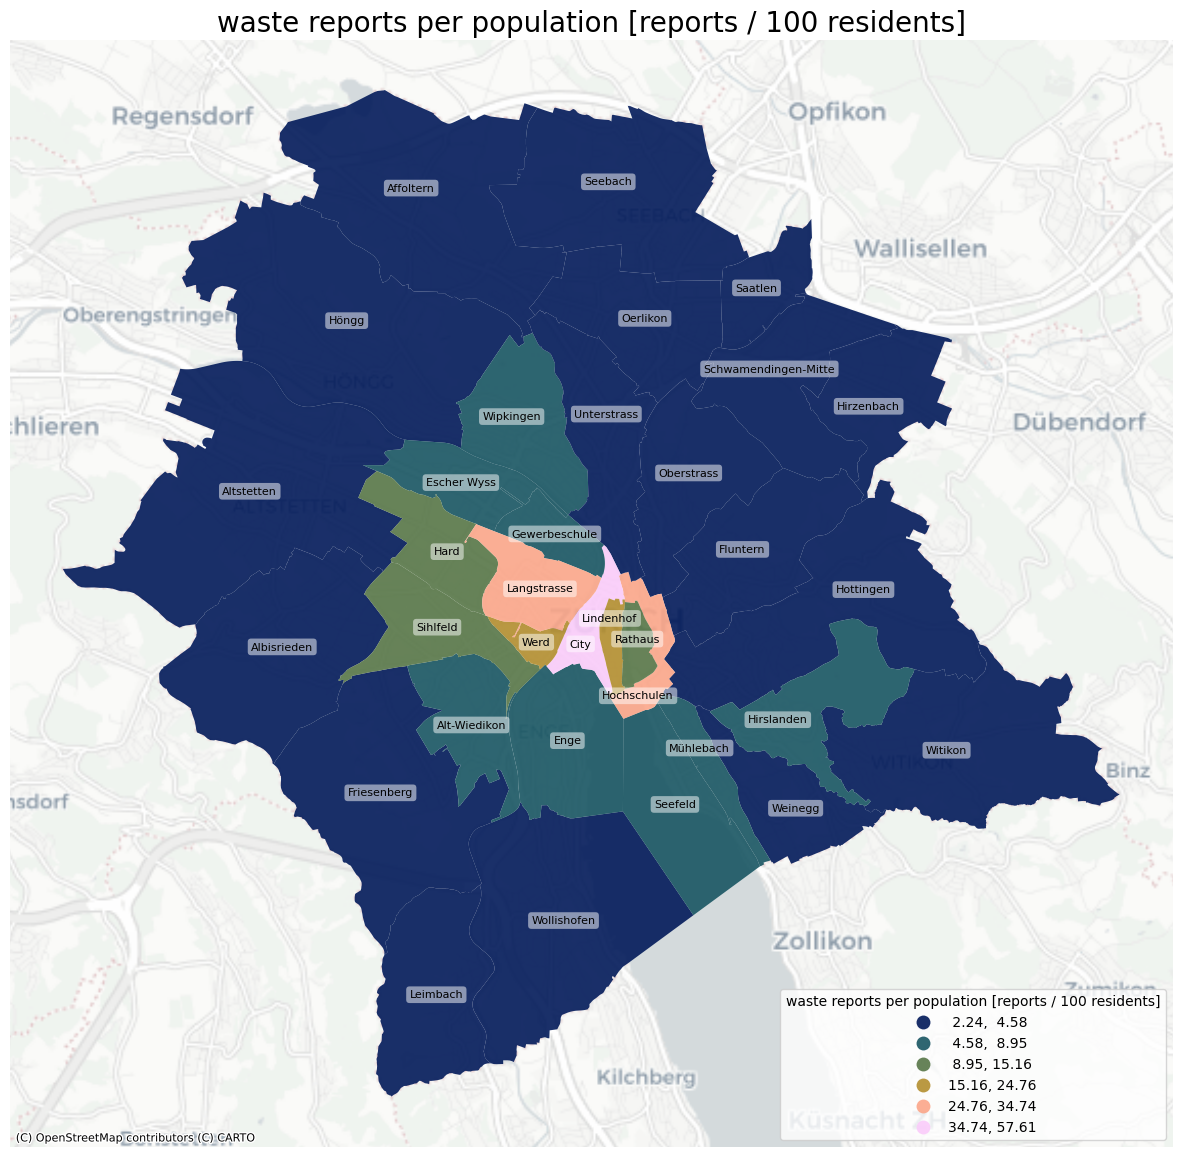

In [ ]:
fig, ax = plt.subplots( figsize= (15,15))

#change to web mercator to be able to plot the contextily tiles on top
waste_pop_gdf.to_crs(epsg=3857).plot(ax=ax, 
                                     column= "waste_per_pop", 
                                     scheme="natural_breaks", 
                                     k=6, 
                                     legend=True,
                                     legend_kwds={"title": "waste reports per population [reports / 100 residents]", "loc": "lower right"}, 
                                     alpha=0.9,
                                     cmap= cmc.batlow)

# hide the x and y axes lines, ticks, and coordinate numbers
ax.axis("off")

# set a title
ax.set_title("waste reports per population [reports / 100 residents]", size=20)

# add basemap
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron)

# add the labels
for idx, row in neighbourhood_labels_gdf.to_crs(epsg=3857).iterrows():
    x, y = row.geometry.x, row.geometry.y

    # change the lindenhof label y coordinate
    if row['name'] == 'Lindenhof':
        y += 200
    
    ax.annotate(
    text=row['name'],
    xy=(x, y),
    fontsize=8,
    ha='center',
    color= "black",
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5, edgecolor='none')
)

plt.show()

Compared to the heatmap, the city neighbourhood has the largest number of waste per population. Apart from this the choropleth map does align quite well with the heatmap, the neighbourhoods around the crossing of the Badener- and Seebahnstrasse (Sihlfeld, Hard, Langstrasse, Werd) do have higher values than the suburban neighbourhoods. So do the central neighbourhoods Lindenhof, Rathaus and Hochschulen.